In [42]:
import seaborn as sns
import pandas as pd

# Load the dataset
df = sns.load_dataset("diamonds")

# Quick inspection
print("--- INFO ---")
df.info()

print("\n--- DESCRIBE ---")
print(df.describe())

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

--- DESCRIBE ---
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     

unico limite, rimuovere solo gli outlier oltre 3 deviazioni standard

Controllo valori nulli


In [43]:
# Conta dei valori mancanti per colonna
print(df.isnull().sum() / len(df) * 100)

carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64


 "Quattro C" (Caratteristiche principali)
carat (numerica): Il peso del diamante (da 0.2 a 5.01).
cut (ordinale): Qualità del taglio (Fair, Good, Very Good, Premium, Ideal).
color (ordinale): Colore del diamante, dal peggiore (J) al migliore (D).
clarity (ordinale): Misura della purezza (I1 (peggiore), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (migliore)). 
Kaggle
Kaggle
Dimensioni e Misurazioni Fisiche
depth (numerica): Percentuale di profondità totale = 
.
table (numerica): Larghezza della parte superiore del diamante rispetto al punto più largo.
x (numerica): Lunghezza in mm.
y (numerica): Larghezza in mm.
z (numerica): Profondità in mm. 
Kaggle
Kaggle
Prezzo
price (intera): Prezzo in dollari USA ($326--$18,823).

# Rimozione POutliers


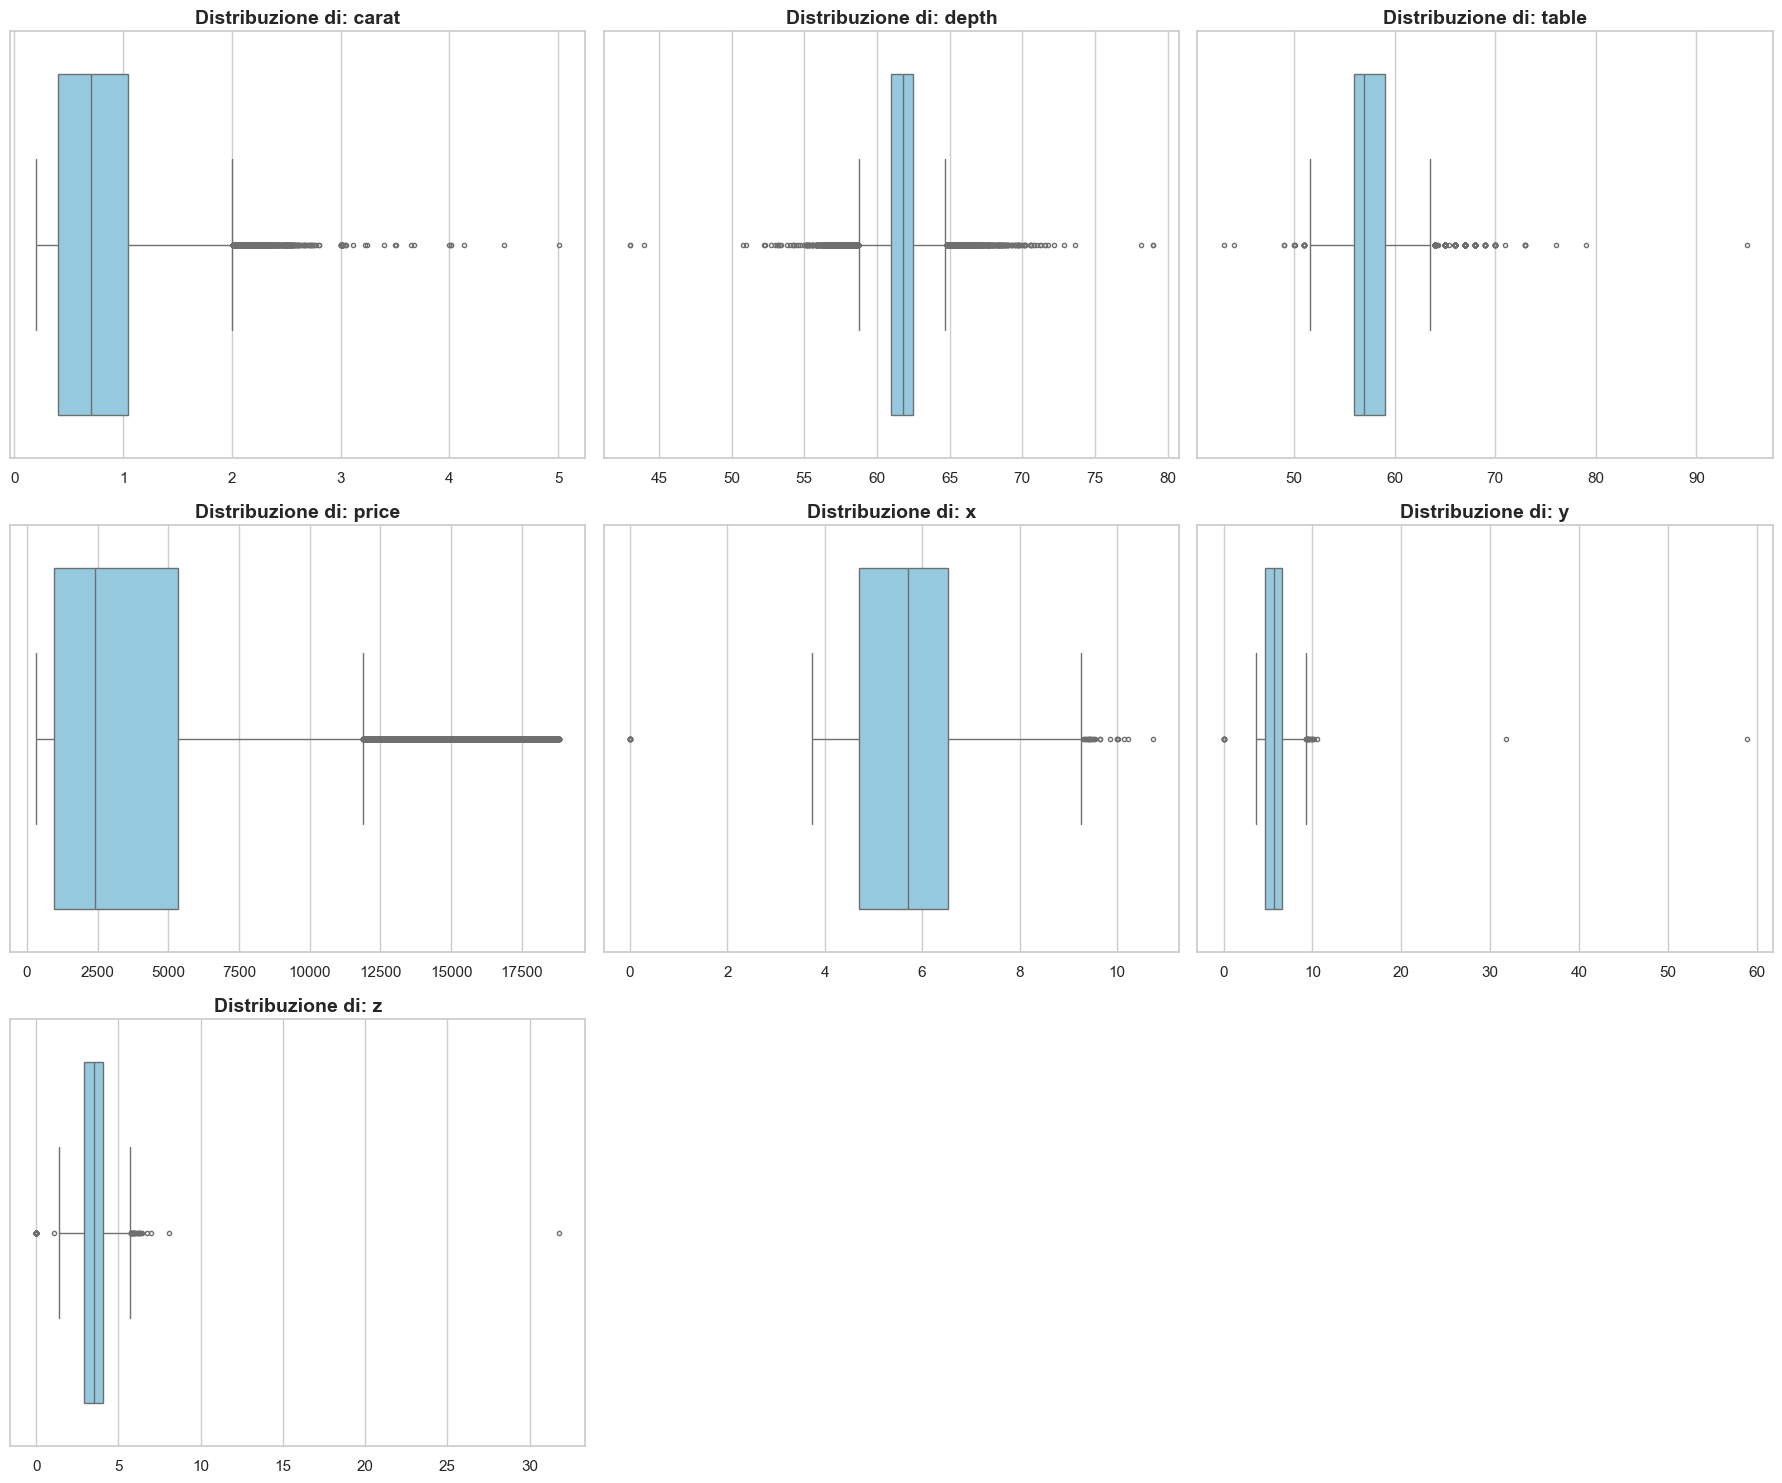

In [44]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [45]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df_encoded = remove_outliers_zscore(df, numeric_cols)
print(f"Righe rimosse con Z-Score: {len(df) - len(df_encoded)}")
df = df_encoded

Righe rimosse con Z-Score: 2350


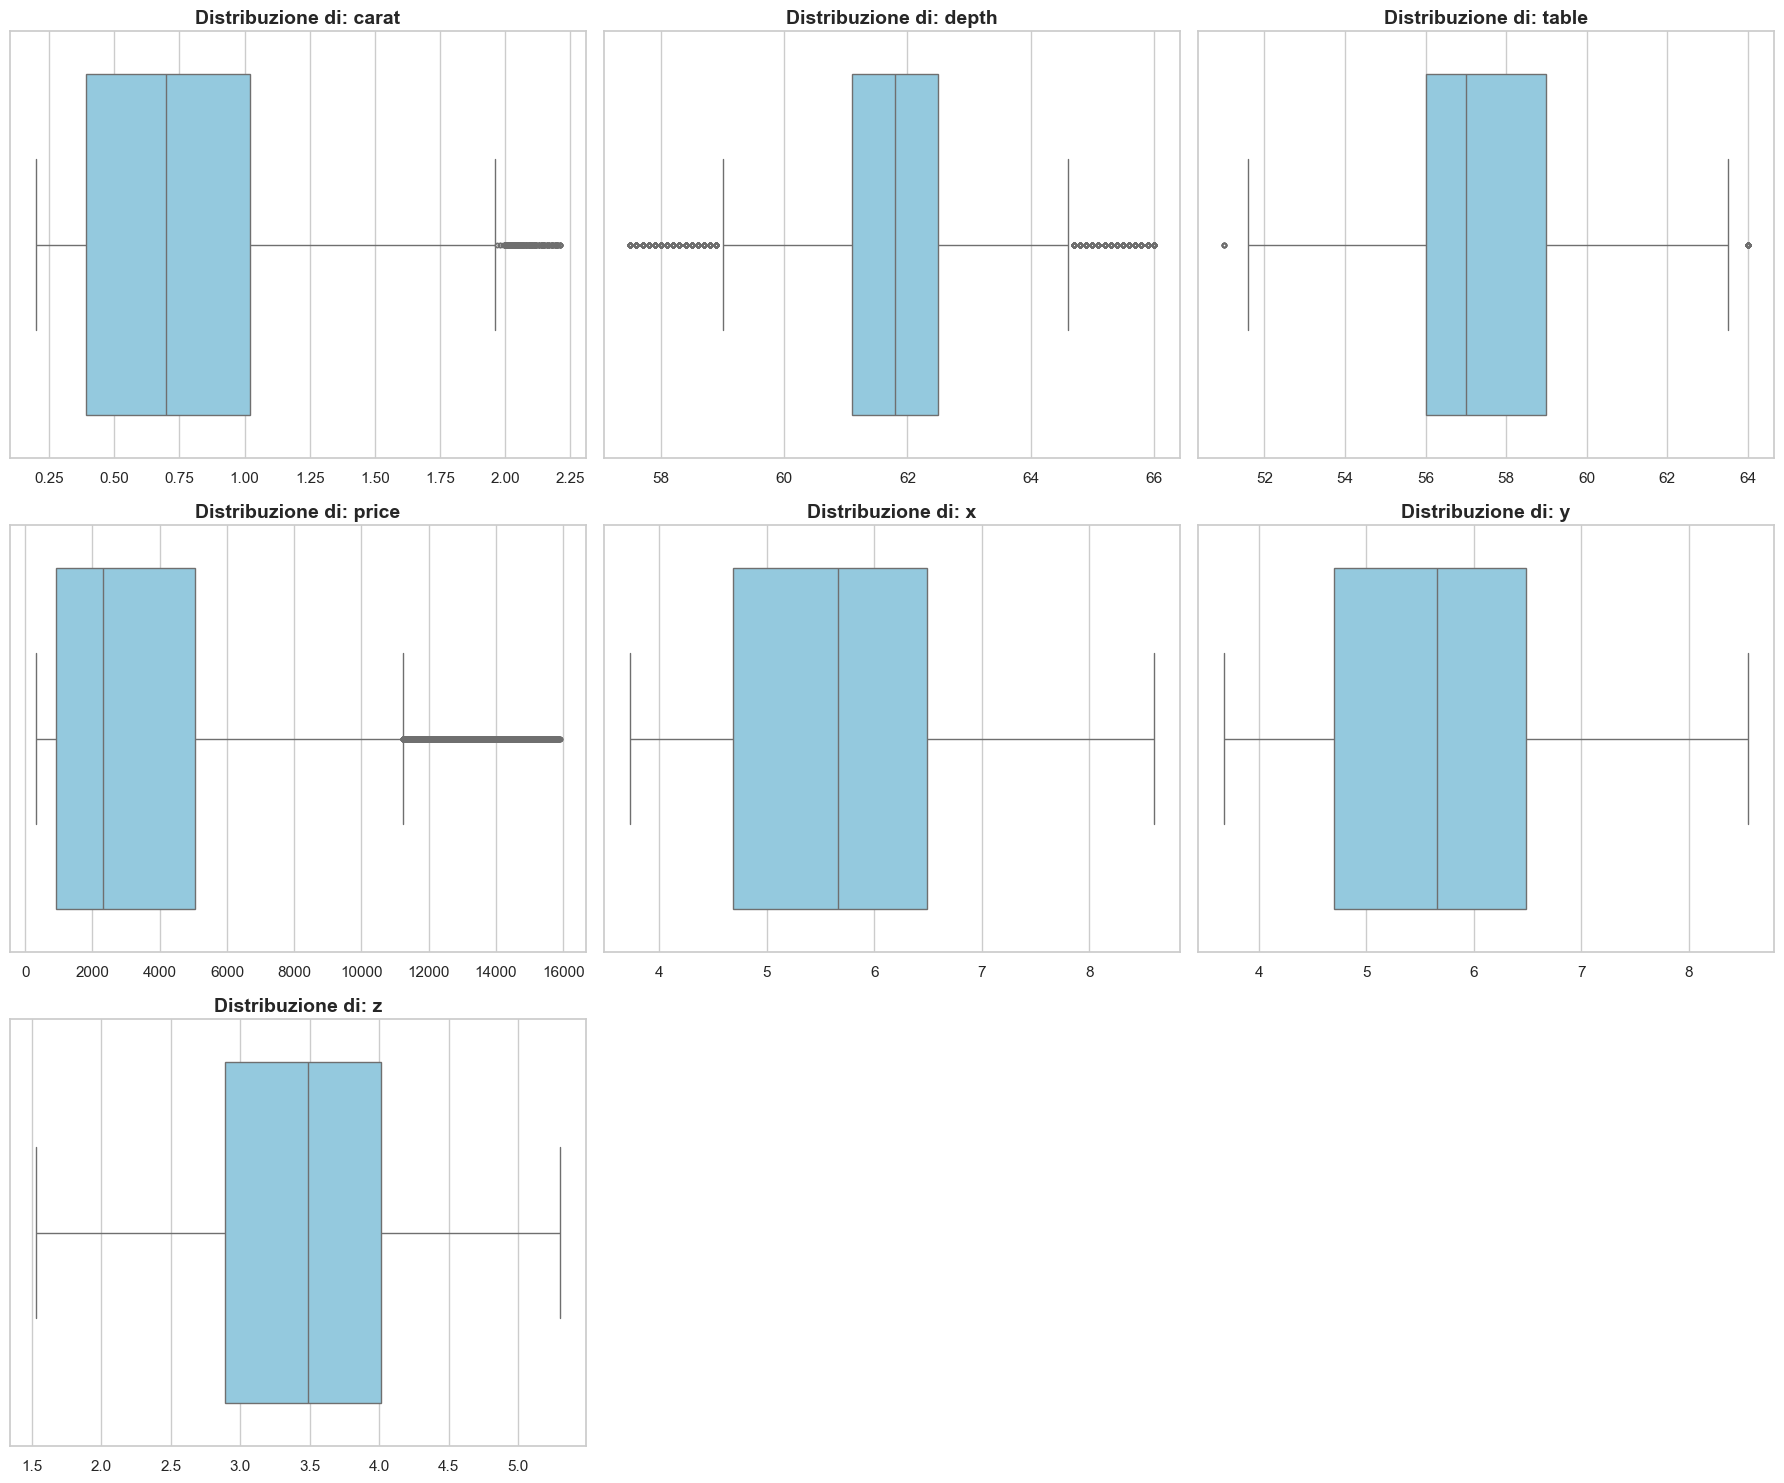

In [46]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

# Feature Engineering


In [47]:
# Creazione della feature Volume
df['volume'] = df['x'] * df['y'] * df['z']

#Check dei dimanti con volume 0
print(f"Diamanti con volume zero: {(df['volume'] == 0).sum()}")

Diamanti con volume zero: 0


In [48]:
#Rapporto Lunghezza/Larghezza (L/W Ratio)
#Indica quanto il diamante è "allungato" rispetto a quanto è "rotondo". Per un diamante tondo ideale, il rapporto è 1.

df['l_w_ratio'] = df['x'] / df['y']

In [49]:
# Poiché il diamante è composto da carbonio puro, la relazione tra peso (carat) e volume dovrebbe essere costante. 
# Anomalie in questo rapporto potrebbero indicare errori nei dati o tagli molto particolari.
df['carat_per_volume'] = df['carat'] / df['volume']

### trasformazione delle colonne non numeriche

In [ ]:
## encoding variab categoriche
import pandas as pd


# # Ciclo per creare boxplot solo per colonne numeriche
# str_cols = df.select_dtypes(include=['object', 'string']).columns
# print(str_cols)

# # Variabili categoriche da trasformare
categorical_cols = ['color', 'cut', 'clarity']

#One-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
# standard scaler
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


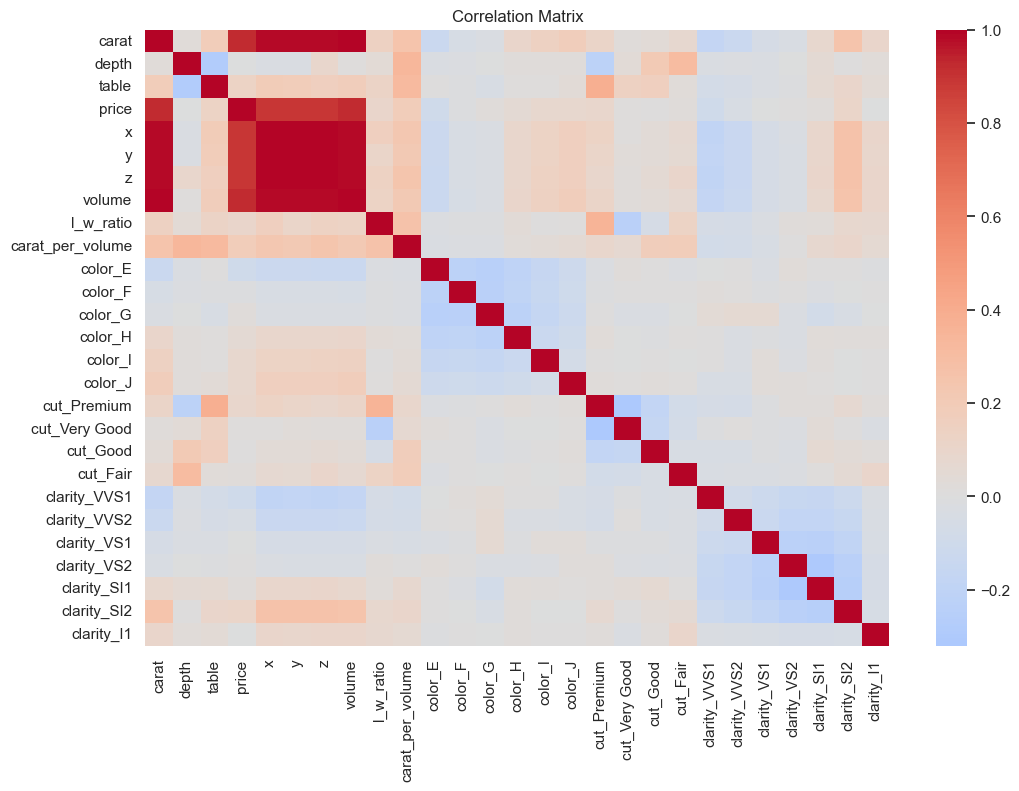

In [ ]:
plt.figure(figsize=(12, 8))

# Solo colonne numeriche
corr = df.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

# Regressione Lineare

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop(columns=['price'])
y = df.price

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'target'